In [1]:
import matplotlib.pyplot as plt
import numpy as np

---

In [2]:
files = [
    'data/jacobi_diag_cpu_test_16_double_metrics.csv',
    'data/jacobi_mg_cpu_test_16_double_metrics.csv',
    'data/gmres_diag_cpu_test_16_double_metrics.csv',
    'data/gmres_mg_cpu_test_16_double_metrics.csv',
]

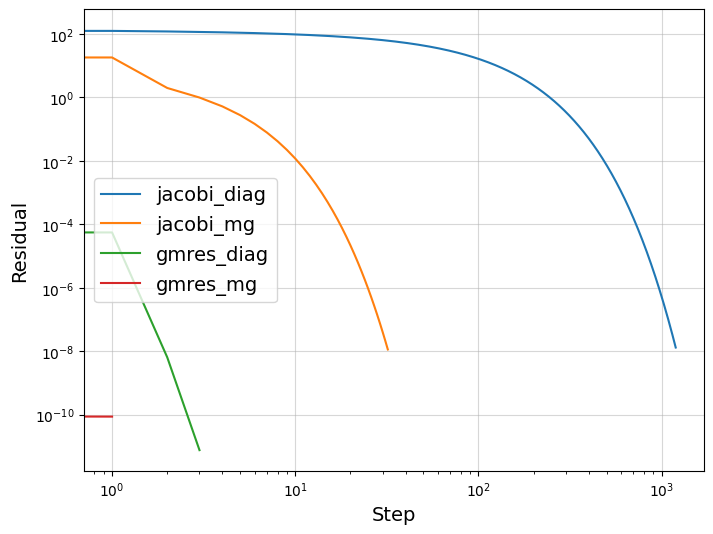

In [8]:
plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)

for file in files:
    data = np.loadtxt(file, delimiter=',', skiprows=1)
    plt.plot(np.arange(len(data[:, 1]), dtype=int), data[:, 1], label='_'.join(file.split('/')[1].split('_')[:2]))

plt.legend(fontsize=14)

plt.xlabel('Step', fontsize=14)
plt.ylabel('Residual', fontsize=14)

plt.xscale('log')
plt.yscale('log')

plt.show()

In [1]:
import numpy as np

# ----------------------------------------
# вспомогательные функции
# ----------------------------------------
def p(x):
    return x - x*x

def phi(x, y, z):
    g = p(x)*p(y)*p(z)
    return g*g


def psi(x, y, z):
    px, py, pz = p(x), p(y), p(z)
    ax, ay, az = 1 - 2*x, 1 - 2*y, 1 - 2*z

    g = px*py*pz

    S = (
        ax*ax * py*py * pz*pz
        + ay*ay * px*px * pz*pz
        + az*az * px*px * py*py
    )

    T = py*pz + px*pz + px*py

    return (
        g**6
        - g**2
        - 2*S
        + 4*g*T
    )


def f(x, y, z):
    px, py, pz = p(x), p(y), p(z)
    ax, ay, az = 1 - 2*x, 1 - 2*y, 1 - 2*z

    g = px*py*pz

    S = (
        ax*ax * py*py * pz*pz
        + ay*ay * px*px * pz*pz
        + az*az * px*px * py*py
    )

    T = py*pz + px*pz + px*py

    return (
        30*g**4 * S
        - 12*g**5 * T
        - 2*S
        + 4*g*T
        - 16*(py*py*pz*pz + px*px*pz*pz + px*px*py*py)
        - 8*T*T
        + 8*(ax*ax*py*pz*(py+pz)
             + ay*ay*px*pz*(px+pz)
             + az*az*px*py*(px+py))
        - 16*g*(px + py + pz)
    )


# ----------------------------------------
# проверка граничных условий
# ----------------------------------------
def check_boundary(n=5, tol=1e-12):
    xs = np.linspace(0, 1, n)

    max_phi = 0.0
    max_psi = 0.0

    for x in xs:
        for y in xs:
            for z in xs:
                # точка на границе куба
                if x in (0, 1) or y in (0, 1) or z in (0, 1):
                    val_phi = abs(phi(x, y, z))
                    val_psi = abs(psi(x, y, z))

                    max_phi = max(max_phi, val_phi)
                    max_psi = max(max_psi, val_psi)

    print("Максимум |phi| на границе :", max_phi)
    print("Максимум |psi| на границе :", max_psi)

    if max_phi < tol and max_psi < tol:
        print("✅ Граничные условия Дирихле выполнены")
    else:
        print("❌ Есть нарушение граничных условий")


# ----------------------------------------
# запуск проверки
# ----------------------------------------
check_boundary()


Максимум |phi| на границе : 0.0
Максимум |psi| на границе : 0.0078125
❌ Есть нарушение граничных условий


In [2]:
import numpy as np
from itertools import product
from numpy.linalg import lstsq

# -------------------------------------------------
# базовые функции
# -------------------------------------------------
def g(x, y, z):
    return x*(1-x)*y*(1-y)*z*(1-z)

def laplacian_phi(x, y, z, a):
    a0,a1,a2,a3,a4,a5,a6 = a

    # P and derivatives
    P = (
        a0
        + a1*x + a2*y + a3*z
        + a4*x*y + a5*x*z + a6*y*z
    )

    # φ = g P
    # Лапласиан φ = P Δg + 2 ∇g·∇P + g ΔP

    # g-derivatives
    gx = (1-2*x)*y*(1-y)*z*(1-z)
    gy = (1-2*y)*x*(1-x)*z*(1-z)
    gz = (1-2*z)*x*(1-x)*y*(1-y)

    gxx = -2*y*(1-y)*z*(1-z)
    gyy = -2*x*(1-x)*z*(1-z)
    gzz = -2*x*(1-x)*y*(1-y)

    lap_g = gxx + gyy + gzz

    # P-derivatives
    Px = a1 + a4*y + a5*z
    Py = a2 + a4*x + a6*z
    Pz = a3 + a5*x + a6*y

    lap_P = 0.0  # P is at most bilinear

    return (
        P*lap_g
        + 2*(gx*Px + gy*Py + gz*Pz)
        + g(x,y,z)*lap_P
    )

# -------------------------------------------------
# собираем систему
# -------------------------------------------------
# точки на границах (фиксируем одну координату = 0 или 1)
vals = [0.25, 0.5, 0.75]
boundary_points = []

for x,y,z in product(vals, vals, vals):
    boundary_points += [
        (0,y,z), (1,y,z),
        (x,0,z), (x,1,z),
        (x,y,0), (x,y,1)
    ]

# линейная система A a = 0
A = []
for x,y,z in boundary_points:
    row = []
    for i in range(7):
        a = np.zeros(7)
        a[i] = 1.0
        row.append(laplacian_phi(x,y,z,a))
    A.append(row)

A = np.array(A)

# решаем
_, _, vh = np.linalg.svd(A)
a = vh[-1]              # ненулевое решение
a /= np.max(np.abs(a))  # нормировка

print("Найденные коэффициенты P:")
print(a)

# -------------------------------------------------
# проверка φ и ψ на границе
# -------------------------------------------------
def phi(x,y,z):
    P = (
        a[0]
        + a[1]*x + a[2]*y + a[3]*z
        + a[4]*x*y + a[5]*x*z + a[6]*y*z
    )
    return g(x,y,z)*P

def psi(x,y,z):
    return -laplacian_phi(x,y,z,a)  # на границе этого достаточно

max_phi = 0.0
max_psi = 0.0

for x,y,z in boundary_points:
    max_phi = max(max_phi, abs(phi(x,y,z)))
    max_psi = max(max_psi, abs(psi(x,y,z)))

print("max |phi| on boundary =", max_phi)
print("max |psi| on boundary =", max_psi)


Найденные коэффициенты P:
[ 0.79793321 -1.         -1.         -1.          0.95973223  0.95973223
  0.95973223]
max |phi| on boundary = 0.0
max |psi| on boundary = 0.06173791594556624


In [8]:
import sympy as sp

# -------------------------------------------------
# символы
# -------------------------------------------------
x, y, z = sp.symbols('x y z')

# -------------------------------------------------
# базовый множитель
# -------------------------------------------------
g = x*(1-x)*y*(1-y)*z*(1-z)

# -------------------------------------------------
# P степени 3
# -------------------------------------------------
coeffs = {}
P = 0
idx = 0
dim = 6
for i in range(dim+1):
    for j in range(dim+1-i):
        for k in range(dim+1-i-j):
            a = sp.symbols(f"a{idx}")
            coeffs[(i,j,k)] = a
            P += a * x**i * y**j * z**k
            idx += 1

# -------------------------------------------------
# phi и лапласиан
# -------------------------------------------------
phi = g * P
lap_phi = sp.diff(phi, x, 2) + sp.diff(phi, y, 2) + sp.diff(phi, z, 2)

# -------------------------------------------------
# собираем условия Δphi = 0 на гранях
# -------------------------------------------------
eqs = []

def collect_face(expr, subs, vars):
    e = sp.expand(expr.subs(subs))
    poly = sp.Poly(e, vars)
    return poly.coeffs()

# x = 0, 1
eqs += collect_face(lap_phi, {x:0}, (y,z))
eqs += collect_face(lap_phi, {x:1}, (y,z))

# y = 0, 1
eqs += collect_face(lap_phi, {y:0}, (x,z))
eqs += collect_face(lap_phi, {y:1}, (x,z))

# z = 0, 1
eqs += collect_face(lap_phi, {z:0}, (x,y))
eqs += collect_face(lap_phi, {z:1}, (x,y))

# -------------------------------------------------
# решаем линейную систему
# -------------------------------------------------
unknowns = list(coeffs.values())
sol = sp.linsolve(eqs, unknowns)

print("Размерность пространства решений:", sol.free_symbols)


Размерность пространства решений: {a60}


In [11]:
import sympy as sp

# ------------------------------------------------------------
# символы
# ------------------------------------------------------------
x, y, z = sp.symbols('x y z')

# ------------------------------------------------------------
# базовый множитель g
# ------------------------------------------------------------
g = x*(1-x)*y*(1-y)*z*(1-z)

# ------------------------------------------------------------
# степень полинома P (МЕНЯЙ ЗДЕСЬ ПРИ НЕОБХОДИМОСТИ)
# ------------------------------------------------------------
P_degree = 6   # <-- у тебя уже сработало при 6

# ------------------------------------------------------------
# строим P = sum_{i+j+k<=P_degree} a_{ijk} x^i y^j z^k
# ------------------------------------------------------------
coeffs = []
P = 0
idx = 0

for i in range(P_degree + 1):
    for j in range(P_degree + 1 - i):
        for k in range(P_degree + 1 - i - j):
            a = sp.symbols(f"a{idx}")
            coeffs.append(a)
            P += a * x**i * y**j * z**k
            idx += 1

print(f"Количество коэффициентов P: {len(coeffs)}")

# ------------------------------------------------------------
# φ и Δφ
# ------------------------------------------------------------
phi = g * P
lap_phi = sp.diff(phi, x, 2) + sp.diff(phi, y, 2) + sp.diff(phi, z, 2)

# ------------------------------------------------------------
# функция: собрать ВСЕ коэффициенты полинома на грани
# ------------------------------------------------------------
def boundary_equations(expr, subs, vars):
    expr_sub = sp.expand(expr.subs(subs))
    poly = sp.Poly(expr_sub, vars)
    return poly.coeffs()

# ------------------------------------------------------------
# собираем условия Δφ = 0 на всех гранях
# ------------------------------------------------------------
equations = []

# x = 0, 1
equations += boundary_equations(lap_phi, {x: 0}, (y, z))
equations += boundary_equations(lap_phi, {x: 1}, (y, z))

# y = 0, 1
equations += boundary_equations(lap_phi, {y: 0}, (x, z))
equations += boundary_equations(lap_phi, {y: 1}, (x, z))

# z = 0, 1
equations += boundary_equations(lap_phi, {z: 0}, (x, y))
equations += boundary_equations(lap_phi, {z: 1}, (x, y))

print(f"Количество уравнений: {len(equations)}")

# ------------------------------------------------------------
# решаем линейную систему
# ------------------------------------------------------------
solution = sp.linsolve(equations, coeffs)

print("\nРешение linsolve:")
print(solution)

# ------------------------------------------------------------
# если пространство решений ненулевое — извлекаем базис
# ------------------------------------------------------------
if solution:
    sol = list(solution)[0]
    free = solution.free_symbols
    print("\nСвободные параметры:", free)

    # пример: фиксируем первый свободный параметр = 1
    if free:
        free_param = list(free)[0]
        sol_fixed = [s.subs(free_param, 1) for s in sol]

        print("\nКонкретное решение (масштаб зафиксирован):")
        for a, v in zip(coeffs, sol_fixed):
            if v != 0:
                print(f"{a} = {sp.simplify(v)}")
else:
    print("Нетривиальных решений нет")


Количество коэффициентов P: 84
Количество уравнений: 258

Решение linsolve:
{(-a60, -a60, a60, 0, 0, 0, 0, -a60, -a60, a60, 0, 0, 0, a60, a60, -a60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -a60, -a60, a60, 0, 0, 0, -a60, -a60, a60, 0, 0, a60, a60, -a60, 0, 0, 0, 0, 0, 0, 0, a60, a60, -a60, 0, 0, a60, a60, -a60, 0, -a60, -a60, a60, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)}

Свободные параметры: {a60}

Конкретное решение (масштаб зафиксирован):
a0 = -1
a1 = -1
a2 = 1
a7 = -1
a8 = -1
a9 = 1
a13 = 1
a14 = 1
a15 = -1
a28 = -1
a29 = -1
a30 = 1
a34 = -1
a35 = -1
a36 = 1
a39 = 1
a40 = 1
a41 = -1
a49 = 1
a50 = 1
a51 = -1
a54 = 1
a55 = 1
a56 = -1
a58 = -1
a59 = -1
a60 = 1


In [12]:
import sympy as sp

# ------------------------------------------------------------
# символы
# ------------------------------------------------------------
x, y, z = sp.symbols('x y z')

# ------------------------------------------------------------
# базовый множитель g
# ------------------------------------------------------------
g = x*(1-x)*y*(1-y)*z*(1-z)

# ------------------------------------------------------------
# степень P
# ------------------------------------------------------------
P_degree = 6

# ------------------------------------------------------------
# строим P
# ------------------------------------------------------------
coeffs = []
P = 0
idx = 0

for i in range(P_degree + 1):
    for j in range(P_degree + 1 - i):
        for k in range(P_degree + 1 - i - j):
            a = sp.symbols(f"a{idx}")
            coeffs.append(a)
            P += a * x**i * y**j * z**k
            idx += 1

# ------------------------------------------------------------
# найденное решение (a60 = 1)
# ------------------------------------------------------------
solution = {
    coeffs[0]:  -1,
    coeffs[1]:  -1,
    coeffs[2]:   1,
    coeffs[7]:  -1,
    coeffs[8]:  -1,
    coeffs[9]:   1,
    coeffs[13]:  1,
    coeffs[14]:  1,
    coeffs[15]: -1,
    coeffs[28]: -1,
    coeffs[29]: -1,
    coeffs[30]:  1,
    coeffs[34]: -1,
    coeffs[35]: -1,
    coeffs[36]:  1,
    coeffs[39]:  1,
    coeffs[40]:  1,
    coeffs[41]: -1,
    coeffs[49]:  1,
    coeffs[50]:  1,
    coeffs[51]: -1,
    coeffs[54]:  1,
    coeffs[55]:  1,
    coeffs[56]: -1,
    coeffs[58]: -1,
    coeffs[59]: -1,
    coeffs[60]:  1,
}

# остальные коэффициенты = 0
for a in coeffs:
    if a not in solution:
        solution[a] = 0

# ------------------------------------------------------------
# подставляем решение в P
# ------------------------------------------------------------
P = sp.expand(P.subs(solution))

# ------------------------------------------------------------
# phi
# ------------------------------------------------------------
phi = sp.expand(g * P)

# ------------------------------------------------------------
# psi
# ------------------------------------------------------------
lap_phi = sp.diff(phi, x, 2) + sp.diff(phi, y, 2) + sp.diff(phi, z, 2)
psi = sp.expand((phi**2 - 1)*phi - lap_phi)

# ------------------------------------------------------------
# f
# ------------------------------------------------------------
lap_psi = sp.diff(psi, x, 2) + sp.diff(psi, y, 2) + sp.diff(psi, z, 2)
f = sp.expand(lap_psi)

# ------------------------------------------------------------
# печать результатов
# ------------------------------------------------------------
print("\n========== P(x,y,z) ==========\n")
print(P)

print("\n========== phi(x,y,z) ==========\n")
print(phi)

print("\n========== psi(x,y,z) ==========\n")
print(psi)

print("\n========== f(x,y,z) ==========\n")
print(f)



========== P(x,y,z) ==========

x**2*y**2*z**2 - x**2*y**2*z - x**2*y**2 - x**2*y*z**2 + x**2*y*z + x**2*y - x**2*z**2 + x**2*z + x**2 - x*y**2*z**2 + x*y**2*z + x*y**2 + x*y*z**2 - x*y*z - x*y + x*z**2 - x*z - x - y**2*z**2 + y**2*z + y**2 + y*z**2 - y*z - y + z**2 - z - 1

========== phi(x,y,z) ==========

-x**4*y**4*z**4 + 2*x**4*y**4*z**3 - x**4*y**4*z + 2*x**4*y**3*z**4 - 4*x**4*y**3*z**3 + 2*x**4*y**3*z - x**4*y*z**4 + 2*x**4*y*z**3 - x**4*y*z + 2*x**3*y**4*z**4 - 4*x**3*y**4*z**3 + 2*x**3*y**4*z - 4*x**3*y**3*z**4 + 8*x**3*y**3*z**3 - 4*x**3*y**3*z + 2*x**3*y*z**4 - 4*x**3*y*z**3 + 2*x**3*y*z - x*y**4*z**4 + 2*x*y**4*z**3 - x*y**4*z + 2*x*y**3*z**4 - 4*x*y**3*z**3 + 2*x*y**3*z - x*y*z**4 + 2*x*y*z**3 - x*y*z

========== psi(x,y,z) ==========

-x**12*y**12*z**12 + 6*x**12*y**12*z**11 - 12*x**12*y**12*z**10 + 5*x**12*y**12*z**9 + 12*x**12*y**12*z**8 - 12*x**12*y**12*z**7 - 3*x**12*y**12*z**6 + 6*x**12*y**12*z**5 - x**12*y**12*z**3 + 6*x**12*y**11*z**12 - 36*x**12*y**11*z**11 + 72

In [ ]:
Пожалуйста отрефактори этот код так, чтобы я мог его вставить в мой репозиторий. Сделай его минималистичным, оставив минимальные комментарии строго на английском! По ходу работы он должен печатать, что ищу решение для psi в виде ... из условия ... . Потом что он нашел методом неопределенных коэффициентов такое-то количество коэффициентов для полинома такой-то степени. И в самом конце он должен написать эти выражения, чтобы я мог скопировать их в cpp код! То есть нельзя использовать ** для возведения в степень. Также было бы красиво, если бы он группировал слагаемые по степеням, например, и писал эти группы с новой строчки. Это было бы более читаймо

In [ ]:
И конечно же в конце нужно сделать проверку того, что он равен нулю на всех границах!!!

In [ ]:
Поскольку у меня оба решения равняются нулю на границах, то получившиеся полиномы можно частично факторизовать вынеся множитель x*(1-x)*y*(1-y)*z*(1-z). Это существенно уменьшит количество слагаемых в полиноме, который идет после. Пожалуйста реализуй это

In [ ]:
Пожалуйста еще раз напиши мне код со всеми изменениями

In [ ]:
import sympy as sp
import numpy as np

x, y, z = sp.symbols("x y z")

P_DEGREE = 6

print("Searching for solution:")
print("  phi(x,y,z) = g(x,y,z) * P(x,y,z)")
print("  psi + Laplacian(phi) - (phi^2 - 1)*phi = 0")
print("  phi = 0 and psi = 0 on the whole boundary\n")

g = x*(1 - x)*y*(1 - y)*z*(1 - z)

coeffs = []
P = 0
idx = 0

for i in range(P_DEGREE + 1):
    for j in range(P_DEGREE + 1 - i):
        for k in range(P_DEGREE + 1 - i - j):
            a = sp.symbols(f"a{idx}")
            coeffs.append(a)
            P += a * x**i * y**j * z**k
            idx += 1

print(f"Polynomial degree        : {P_DEGREE}")
print(f"Number of coefficients   : {len(coeffs)}")

phi = g * P
lap_phi = sp.diff(phi, x, 2) + sp.diff(phi, y, 2) + sp.diff(phi, z, 2)

def collect_coeffs(expr, subs, vars):
    poly = sp.Poly(sp.expand(expr.subs(subs)), vars)
    return poly.coeffs()

equations = []
equations += collect_coeffs(lap_phi, {x: 0}, (y, z))
equations += collect_coeffs(lap_phi, {x: 1}, (y, z))
equations += collect_coeffs(lap_phi, {y: 0}, (x, z))
equations += collect_coeffs(lap_phi, {y: 1}, (x, z))
equations += collect_coeffs(lap_phi, {z: 0}, (x, y))
equations += collect_coeffs(lap_phi, {z: 1}, (x, y))

print(f"Number of equations      : {len(equations)}")

solution = sp.linsolve(equations, coeffs)
free = list(solution.free_symbols)

print(f"Solution space dimension : {len(free)}")

if not free:
    raise RuntimeError("No non-trivial solution")

sol = list(solution)[0]
sol = [s.subs(free[0], 1) for s in sol]

P = sp.expand(P.subs(dict(zip(coeffs, sol))))
phi = g * P

lap_phi = sp.diff(phi, x, 2) + sp.diff(phi, y, 2) + sp.diff(phi, z, 2)
psi = sp.expand((phi**2 - 1)*phi - lap_phi)

lap_psi = sp.diff(psi, x, 2) + sp.diff(psi, y, 2) + sp.diff(psi, z, 2)
f = sp.expand(lap_psi)

def group_by_degree(expr):
    poly = sp.Poly(expr, x, y, z)
    groups = {}
    for monom, coeff in poly.terms():
        deg = sum(monom)
        term = coeff
        for v, p in zip((x, y, z), monom):
            if p > 0:
                term *= v**p
        groups.setdefault(deg, []).append(term)
    return groups

def print_cpp_grouped(expr, indent="  "):
    groups = group_by_degree(expr)
    first = True
    for deg in sorted(groups):
        line = ""
        for t in groups[deg]:
            c = sp.Poly(t, x, y, z).coeff_monomial(
                x**sp.degree(t, x) *
                y**sp.degree(t, y) *
                z**sp.degree(t, z)
            )
            neg = c.could_extract_minus_sign()
            term = sp.ccode(-t if neg else t)
            if first:
                if neg:
                    line += "-"
                line += term
                first = False
            else:
                line += " - " + term if neg else " + " + term
        print(indent + line)

def try_factor_by_g(expr):
    r = sp.expand(sp.cancel(expr / g))
    if r.is_polynomial(x, y, z):
        return r
    return None

print("\n=== GENERATED EXPRESSIONS (C/C++) ===\n")

print("base factor")
print("g = x*(1-x)*y*(1-y)*z*(1-z);\n")

print("polynomial P")
print_cpp_grouped(P)
print()

print("phi(x,y,z) =")
print("g * (")
print_cpp_grouped(P)
print(")\n")

print("psi(x,y,z) =")
psi_r = try_factor_by_g(psi)
if psi_r is not None:
    print("g * (")
    print_cpp_grouped(psi_r)
    print(")\n")
else:
    print_cpp_grouped(psi)
    print()

print("f(x, y, z) =")
print_cpp_grouped(f)
print()

phi_f = sp.lambdify((x, y, z), phi, "numpy")
psi_f = sp.lambdify((x, y, z), psi, "numpy")

vals = np.linspace(0.0, 1.0, 6)
max_phi = 0.0
max_psi = 0.0

for X in vals:
    for Y in vals:
        for Z in vals:
            if X in (0.0, 1.0) or Y in (0.0, 1.0) or Z in (0.0, 1.0):
                max_phi = max(max_phi, abs(phi_f(X, Y, Z)))
                max_psi = max(max_psi, abs(psi_f(X, Y, Z)))

print("=== BOUNDARY VERIFICATION ===")
print(f"max |phi| on boundary = {max_phi:.3e}")
print(f"max |psi| on boundary = {max_psi:.3e}")


Searching for solution:
  phi(x,y,z) = g(x,y,z) * P(x,y,z)
  psi + Laplacian(phi) - (phi^2 - 1)*phi = 0
  phi = 0 and psi = 0 on the whole boundary

Polynomial degree        : 6
Number of coefficients   : 84
Number of equations      : 258
Solution space dimension : 1

=== GENERATED EXPRESSIONS (C/C++) ===

base factor
g = x*(1-x)*y*(1-y)*z*(1-z);

polynomial P
  -1
   - x - y - z
   + pow(x, 2) - x*y - x*z + pow(y, 2) - y*z + pow(z, 2)
   + pow(x, 2)*y + pow(x, 2)*z + x*pow(y, 2) - x*y*z + x*pow(z, 2) + pow(y, 2)*z + y*pow(z, 2)
   - pow(x, 2)*pow(y, 2) + pow(x, 2)*y*z - pow(x, 2)*pow(z, 2) + x*pow(y, 2)*z + x*y*pow(z, 2) - pow(y, 2)*pow(z, 2)
   - pow(x, 2)*pow(y, 2)*z - pow(x, 2)*y*pow(z, 2) - x*pow(y, 2)*pow(z, 2)
   + pow(x, 2)*pow(y, 2)*pow(z, 2)

phi(x,y,z)
phi = g * (
  -1
   - x - y - z
   + pow(x, 2) - x*y - x*z + pow(y, 2) - y*z + pow(z, 2)
   + pow(x, 2)*y + pow(x, 2)*z + x*pow(y, 2) - x*y*z + x*pow(z, 2) + pow(y, 2)*z + y*pow(z, 2)
   - pow(x, 2)*pow(y, 2) + pow(x, 2)*y*z -